# Empirical Results on the MALL 5-min Feature Set


**Purpose:** This notebook summarizes the out-of-sample forecasting performance of all models estimated on the $\mathcal{M}_{\mathrm{ALL}}$ 5-min feature set for the EURO STOXX 50 index. The notebook loads the saved forecast files and MSE summaries, aligns all forecasts on the common MALL test period, constructs a pairwise relative-MSE table with one-sided Diebold-Mariano significance markers, and visualizes the ranking of all models relative to the standard HAR benchmark.

**Important note on interpretation:** The table below is a **single-index adaptation** of Table 2 in Christensen et al. (2023). In the paper, the Diebold-Mariano evidence is summarized across many individual stock-level tests. Here, we only have one forecast-error time series for the EURO STOXX 50 index, so the asterisks should be interpreted as **time-series significance for this single index**, not as a cross-sectional frequency statement across constituents.

**Benchmark-model convention:** Since `HAR`, `LogHAR`, `LevHAR`, `SHAR`, and `HARQ` are unchanged when moving from $\mathcal{M}_{\mathrm{HAR}}$ to $\mathcal{M}_{\mathrm{ALL}}$, those benchmark forecasts and MSE summaries are loaded from the MHAR benchmark-model folder. Only `HAR-X` is loaded from the MALL benchmark-model folder, because the exogenous predictor set changes in that specification.


## 1. Imports and Paths
Defining the relevant directory structure for the saved MALL forecast and MSE files.


In [115]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.style.use("default")

forecast_root_mhar = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR")
forecast_root_mall = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL")
mse_root_mhar = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR")
mse_root_mall = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL")


## 2. Load Saved Result Files
Registering the forecast and MSE summary files for all model classes in a structured way.


In [118]:
model_specs = [
    {
        "display_name": "HAR",
        "forecast_file": forecast_root_mhar / "Benchmark Models" / "forecasts_HAR.csv",
        "mse_file": mse_root_mhar / "Benchmark Models" / "mse_summary_HAR.csv",
        "forecast_column": "RV_forecast",
        "mse_model_name": "HARX",
    },
    {
        "display_name": "HAR-X",
        "forecast_file": forecast_root_mall / "Benchmark Models" / "forecasts_HARX.csv",
        "mse_file": mse_root_mall / "Benchmark Models" / "mse_summary_HARX.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "LogHAR",
        "forecast_file": forecast_root_mhar / "Benchmark Models" / "forecasts_LogHAR.csv",
        "mse_file": mse_root_mhar / "Benchmark Models" / "mse_summary_LogHAR.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "LevHAR",
        "forecast_file": forecast_root_mhar / "Benchmark Models" / "forecasts_LevHAR.csv",
        "mse_file": mse_root_mhar / "Benchmark Models" / "mse_summary_LevHAR.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "SHAR",
        "forecast_file": forecast_root_mhar / "Benchmark Models" / "forecasts_SHAR.csv",
        "mse_file": mse_root_mhar / "Benchmark Models" / "mse_summary_SHAR.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "HARQ",
        "forecast_file": forecast_root_mhar / "Benchmark Models" / "forecasts_HARQ.csv",
        "mse_file": mse_root_mhar / "Benchmark Models" / "mse_summary_HARQ.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "RR",
        "forecast_file": forecast_root_mall / "Regularized Linear Models" / "forecasts_RR.csv",
        "mse_file": mse_root_mall / "Regularized Linear Models" / "mse_summary_RR.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "LA",
        "forecast_file": forecast_root_mall / "Regularized Linear Models" / "forecasts_LA.csv",
        "mse_file": mse_root_mall / "Regularized Linear Models" / "mse_summary_LA.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "EN",
        "forecast_file": forecast_root_mall / "Regularized Linear Models" / "forecasts_EN.csv",
        "mse_file": mse_root_mall / "Regularized Linear Models" / "mse_summary_EN.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "BG",
        "forecast_file": forecast_root_mall / "Tree-based Models" / "forecasts_BG.csv",
        "mse_file": mse_root_mall / "Tree-based Models" / "mse_summary_BG.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "RF",
        "forecast_file": forecast_root_mall / "Tree-based Models" / "forecasts_RF.csv",
        "mse_file": mse_root_mall / "Tree-based Models" / "mse_summary_RF.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "GB",
        "forecast_file": forecast_root_mall / "Tree-based Models" / "forecasts_GB.csv",
        "mse_file": mse_root_mall / "Tree-based Models" / "mse_summary_GB.csv",
        "forecast_column": "RV_forecast",
    },
    {
        "display_name": "NN1_best",
        "forecast_file": forecast_root_mall / "Neural Networks" / "forecasts_NN1.csv",
        "mse_file": mse_root_mall / "Neural Networks" / "mse_summary_NN1.csv",
        "forecast_column": "RV_forecast_best",
    },
    {
        "display_name": "NN1_top10",
        "forecast_file": forecast_root_mall / "Neural Networks" / "forecasts_NN1.csv",
        "mse_file": mse_root_mall / "Neural Networks" / "mse_summary_NN1.csv",
        "forecast_column": "RV_forecast_top10",
    },
    {
        "display_name": "NN2_best",
        "forecast_file": forecast_root_mall / "Neural Networks" / "forecasts_NN2.csv",
        "mse_file": mse_root_mall / "Neural Networks" / "mse_summary_NN2.csv",
        "forecast_column": "RV_forecast_best",
    },
    {
        "display_name": "NN2_top10",
        "forecast_file": forecast_root_mall / "Neural Networks" / "forecasts_NN2.csv",
        "mse_file": mse_root_mall / "Neural Networks" / "mse_summary_NN2.csv",
        "forecast_column": "RV_forecast_top10",
    },
    {
        "display_name": "NN3_best",
        "forecast_file": forecast_root_mall / "Neural Networks" / "forecasts_NN3.csv",
        "mse_file": mse_root_mall / "Neural Networks" / "mse_summary_NN3.csv",
        "forecast_column": "RV_forecast_best",
    },
    {
        "display_name": "NN3_top10",
        "forecast_file": forecast_root_mall / "Neural Networks" / "forecasts_NN3.csv",
        "mse_file": mse_root_mall / "Neural Networks" / "mse_summary_NN3.csv",
        "forecast_column": "RV_forecast_top10",
    },
]

model_order = [spec["display_name"] for spec in model_specs]
registry_df = pd.DataFrame(model_specs)[["display_name", "forecast_file", "mse_file", "forecast_column"]]
print(f"Number of model entries: {len(registry_df)}")
display(registry_df)


Number of model entries: 18


,display_name,forecast_file,mse_file,forecast_column
0,HAR,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
1,HAR-X,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
2,LogHAR,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
3,LevHAR,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
4,SHAR,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
5,HARQ,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
6,RR,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
7,LA,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
8,EN,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast
9,BG,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,/Users/tobiasbergdahlpersson/Documents/SSE/MSc...,RV_forecast


## 3. Combine MSE Summaries
Loading and combining the saved model-level MSE summaries for quick reference.


In [121]:
mse_rows = []
for spec in model_specs:
    mse_df = pd.read_csv(spec["mse_file"])
    mse_df.insert(0, "Display_Name", spec["display_name"])
    mse_rows.append(mse_df)

mse_summary_all = pd.concat(mse_rows, ignore_index=True)
mse_summary_all = mse_summary_all.drop_duplicates(subset=["Display_Name"], keep="first")
mse_summary_all = mse_summary_all.set_index("Display_Name").loc[model_order].reset_index()

print("Combined MSE summary table:")
display(mse_summary_all)


Combined MSE summary table:


,Display_Name,Model,MSE,RMSE,MAE,Mean_Error
0,HAR,HAR,5.663594e-08,0.000238,0.000053,-7.213307e-06
1,HAR-X,HARX,5.277243e-08,0.000230,0.000054,8.305782e-06
2,LogHAR,LogHAR,5.301097e-08,0.000230,0.000046,3.008511e-06
3,LevHAR,LevHAR,5.385192e-08,0.000232,0.000055,-5.312280e-06
4,SHAR,SHAR,5.837974e-08,0.000242,0.000053,-7.666438e-06
5,HARQ,HARQ,4.792463e-08,0.000219,0.000044,-4.991111e-07
6,RR,RR,5.207367e-08,0.000228,0.000065,-2.339699e-05
7,LA,LA,5.077819e-08,0.000225,0.000054,-1.279487e-05
8,EN,EN,5.079268e-08,0.000225,0.000054,-1.289204e-05
9,BG,BG,5.369518e-08,0.000232,0.000047,-1.163969e-05


## 4. Load Forecast Files and Construct a Unified Evaluation Panel
The saved forecast files are not perfectly uniform across model classes. Some notebooks save the date index as `Date`, while others save it as `Unnamed: 0`. The helper functions below standardize the date column and construct one aligned forecast panel with a single forecast series per model.


In [124]:
def load_forecast_file(file_path: Path, forecast_column: str, display_name: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)

    if "Date" in df.columns:
        date_col = "Date"
    elif "Unnamed: 0" in df.columns:
        date_col = "Unnamed: 0"
    else:
        raise ValueError(f"No recognized date column found in {file_path}")

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.rename(columns={date_col: "Date"})

    required_cols = ["Date", "RV_actual", forecast_column]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing} in {file_path}")

    df = df[required_cols].copy()
    df = df.rename(columns={forecast_column: display_name})
    return df

forecast_panel = None
for spec in model_specs:
    df_model = load_forecast_file(spec["forecast_file"], spec["forecast_column"], spec["display_name"])
    if forecast_panel is None:
        forecast_panel = df_model[["Date", "RV_actual"]].copy()
    forecast_panel = forecast_panel.merge(df_model[["Date", spec["display_name"]]], on="Date", how="inner")

forecast_panel = forecast_panel.sort_values("Date").reset_index(drop=True)
forecast_panel = forecast_panel.dropna()

available_models = [m for m in model_order if m in forecast_panel.columns]
actual = forecast_panel["RV_actual"]

print(f"Common evaluation sample: {len(forecast_panel)} observations")
print(f"Evaluation period: {forecast_panel['Date'].min().date()} to {forecast_panel['Date'].max().date()}")
print(f"Number of aligned models: {len(available_models)}")
print("Aligned model list:")
for model in available_models:
    print(f"  - {model}")

forecast_panel.head()


Common evaluation sample: 1099 observations
Evaluation period: 2016-04-21 to 2020-08-06
Number of aligned models: 18
Aligned model list:
  - HAR
  - HAR-X
  - LogHAR
  - LevHAR
  - SHAR
  - HARQ
  - RR
  - LA
  - EN
  - BG
  - RF
  - GB
  - NN1_best
  - NN1_top10
  - NN2_best
  - NN2_top10
  - NN3_best
  - NN3_top10


,Date,RV_actual,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,EN,BG,RF,GB,NN1_best,NN1_top10,NN2_best,NN2_top10,NN3_best,NN3_top10
0,2016-04-21,0.000053,0.000101,0.000039,0.000098,0.000053,0.000099,0.000104,0.000087,0.000082,0.000082,0.000088,0.000083,0.000088,0.000116,0.000096,0.000103,0.000098,0.000097,0.000107
1,2016-04-22,0.000081,0.000085,0.000057,0.000080,0.000065,0.000087,0.000070,0.000090,0.000077,0.000078,0.000062,0.000066,0.000078,0.000093,0.000089,0.000078,0.000086,0.000088,0.000091
2,2016-04-25,0.000066,0.000090,0.000073,0.000087,0.000081,0.000092,0.000085,0.000108,0.000092,0.000093,0.000100,0.000087,0.000086,0.000089,0.000095,0.000106,0.000101,0.000107,0.000107
3,2016-04-26,0.000059,0.000087,0.000072,0.000084,0.000058,0.000088,0.000077,0.000103,0.000091,0.000091,0.000097,0.000091,0.000086,0.000092,0.000099,0.000095,0.000098,0.000119,0.000103
4,2016-04-27,0.000097,0.000084,0.000076,0.000080,0.000068,0.000085,0.000072,0.000102,0.000091,0.000091,0.000080,0.000080,0.000079,0.000085,0.000096,0.000090,0.000095,0.000103,0.000099


## 5. Pairwise Relative MSE and Diebold--Mariano Test
For each ordered model pair $(i, j)$, the table reports the out-of-sample realized-variance forecast MSE of model $j$ relative to model $i$, i.e. $MSE_j / MSE_i$. The significance markers come from a **one-sided** Diebold-Mariano test under squared-error loss, where the null is equal predictive accuracy and the alternative is that the **column** model has lower MSE than the **row** model.

In other words, for each pair we test:

$$
H_0: \mathbb{E}[d_t] = 0, \quad H_1: \mathbb{E}[d_t] > 0,
$$

where

$$
d_t = e_{i,t}^2 - e_{j,t}^2.
$$

Thus, stars on entry $(i, j)$ indicate evidence that the **column model** outperforms the **row model** for the EURO STOXX 50 index.


In [127]:
display_label_map = {
    "HAR": "HAR",
    "HAR-X": "HAR-X",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "BG": "BG",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": "NN¹₁",
    "NN1_top10": "NN¹⁰₁",
    "NN2_best": "NN¹₂",
    "NN2_top10": "NN¹⁰₂",
    "NN3_best": "NN¹₃",
    "NN3_top10": "NN¹⁰₃",
}


def dm_test_one_sided(actual: pd.Series, forecast_i: pd.Series, forecast_j: pd.Series, h: int = 1):
    aligned = pd.concat([actual, forecast_i, forecast_j], axis=1).dropna()
    y = aligned.iloc[:, 0].to_numpy(dtype=float)
    f_i = aligned.iloc[:, 1].to_numpy(dtype=float)
    f_j = aligned.iloc[:, 2].to_numpy(dtype=float)

    d = (y - f_i) ** 2 - (y - f_j) ** 2
    T = len(d)
    if T < 5:
        return np.nan, np.nan

    mean_d = float(d.mean())
    centered = d - mean_d
    long_run_var = float(np.mean(centered ** 2))

    if long_run_var <= 1e-20:
        if abs(mean_d) <= 1e-20:
            return mean_d, 1.0
        return mean_d, 0.0 if mean_d > 0 else 1.0

    dm_stat = mean_d / np.sqrt(long_run_var / T)
    hln_adj = np.sqrt((T + 1 - 2 * h + (h * (h - 1)) / T) / T)
    dm_hln = dm_stat * hln_adj
    p_value = float(1 - stats.t.cdf(dm_hln, df=T - 1))
    return mean_d, p_value


def star_label(p_value: float) -> str:
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


mse_by_model = {model: float(np.mean((actual - forecast_panel[model]) ** 2)) for model in available_models}
relative_mse_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
dm_pvalue_matrix = pd.DataFrame(index=available_models, columns=available_models, dtype=float)
pairwise_relative_mse_table = pd.DataFrame(index=available_models, columns=available_models, dtype=object)

for row_model in available_models:
    for col_model in available_models:
        if row_model == col_model:
            relative_mse_matrix.loc[row_model, col_model] = np.nan
            dm_pvalue_matrix.loc[row_model, col_model] = np.nan
            pairwise_relative_mse_table.loc[row_model, col_model] = "-"
            continue

        rel_mse = mse_by_model[col_model] / mse_by_model[row_model]
        _, p_value = dm_test_one_sided(actual, forecast_panel[row_model], forecast_panel[col_model], h=1)
        relative_mse_matrix.loc[row_model, col_model] = rel_mse
        dm_pvalue_matrix.loc[row_model, col_model] = p_value
        pairwise_relative_mse_table.loc[row_model, col_model] = f"{rel_mse:.3f}{star_label(p_value)}"

pairwise_relative_mse_display = pairwise_relative_mse_table.rename(index=display_label_map, columns=display_label_map)

styled_relative_mse = (
    pairwise_relative_mse_display.style
    .set_caption("Table: One-day-ahead relative MSE and Diebold-Mariano test for dataset M_ALL")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "thead th", "props": [("font-size", "12px"), ("text-align", "center"), ("border-bottom", "1px solid black"), ("padding", "6px")]},
        {"selector": "tbody th", "props": [("font-size", "12px"), ("text-align", "left"), ("padding", "6px"), ("font-weight", "bold")]},
        {"selector": "tbody td", "props": [("font-size", "12px"), ("text-align", "center"), ("padding", "6px")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]}
    ])
)

display(styled_relative_mse)


,HAR,HAR-X,LogHAR,LevHAR,SHAR,HARQ,RR,LA,EN,BG,RF,GB,NN¹₁,NN¹⁰₁,NN¹₂,NN¹⁰₂,NN¹₃,NN¹⁰₃
HAR,-,0.932*,0.936**,0.951,1.031,0.846**,0.919*,0.897**,0.897**,0.948,0.855*,0.992,0.876**,0.922*,0.989,0.921*,0.896*,0.923
HAR-X,1.073,-,1.005,1.020,1.106,0.908**,0.987,0.962*,0.962*,1.017,0.917,1.065,0.941*,0.990,1.062,0.989,0.961,0.990
LogHAR,1.068,0.996,-,1.016,1.101,0.904**,0.982,0.958**,0.958**,1.013,0.913,1.060,0.936*,0.985,1.057,0.984,0.957,0.986
LevHAR,1.052,0.980,0.984,-,1.084,0.890**,0.967,0.943*,0.943*,0.997,0.899*,1.043,0.922**,0.970,1.040,0.969,0.942*,0.970
SHAR,0.970,0.904*,0.908*,0.922,-,0.821**,0.892*,0.870**,0.870**,0.920,0.829*,0.962,0.850*,0.894,0.960,0.894*,0.869*,0.895
HARQ,1.182,1.101,1.106,1.124,1.218,-,1.087,1.060,1.060,1.120,1.010,1.172,1.036,1.090,1.169,1.089,1.059,1.090
RR,1.088,1.013,1.018,1.034,1.121,0.920*,-,0.975*,0.975*,1.031,0.929,1.079,0.953,1.003,1.076,1.002,0.974,1.003
LA,1.115,1.039,1.044,1.061,1.150,0.944,1.026,-,1.000,1.057,0.953,1.107,0.978,1.028,1.103,1.027,0.999,1.029
EN,1.115,1.039,1.044,1.060,1.149,0.944,1.025,1.000**,-,1.057,0.953,1.106,0.977,1.028,1.103,1.027,0.999,1.029
BG,1.055,0.983,0.987,1.003,1.087,0.893,0.970,0.946,0.946,-,0.901**,1.046,0.924,0.973,1.043,0.972,0.945,0.973


**Notes:** Each entry reports the out-of-sample realized-variance forecast MSE of the selected **column** model relative to the selected **row** model. Thus, values below `1.000` indicate that the column model has a lower MSE than the row model. The significance markers are based on a one-sided Diebold-Mariano test under squared-error loss, where the alternative is that the **column** model outperforms the **row** model. Because this notebook applies the comparison to a single EURO STOXX 50 time series, the stars should be interpreted as time-series test results rather than the paper's cross-sectional significance summary across many assets.


## 6. Relative MSE Ranking vs HAR
The chart below ranks all models from best to worst according to their relative MSE against the standard HAR model. Values below `1.0` indicate that the model improves on HAR, while values above `1.0` indicate weaker performance than HAR.


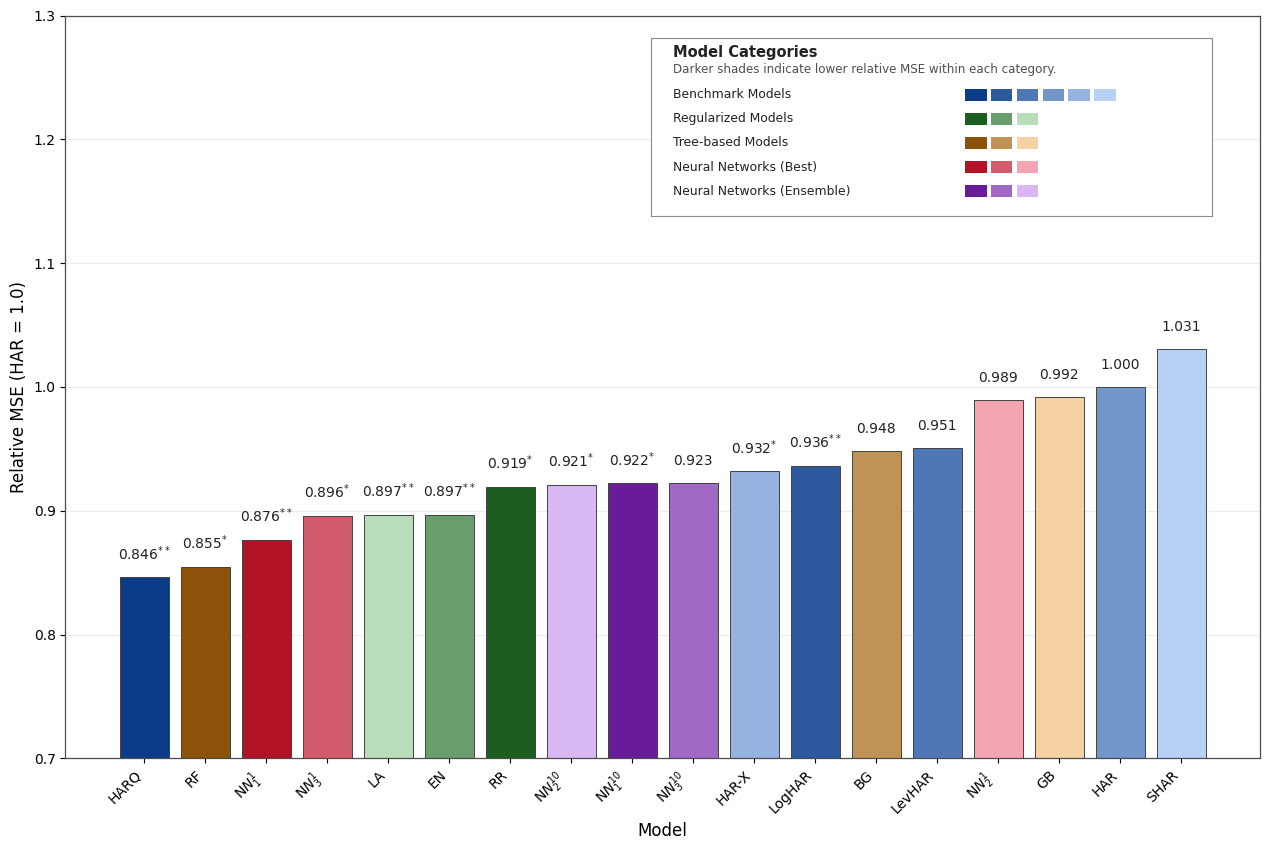

In [131]:
relative_to_har = pd.Series({model: mse / mse_by_model["HAR"] for model, mse in mse_by_model.items()})
relative_to_har = relative_to_har.loc[available_models].sort_values()

from matplotlib.patches import Rectangle


def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)], dtype=float)


def rgb_to_hex(rgb):
    rgb = np.clip(np.round(rgb), 0, 255).astype(int)
    return "#%02x%02x%02x" % tuple(rgb)


def interpolate_hex(start_hex, end_hex, n):
    if n <= 0:
        return []
    if n == 1:
        return [start_hex]
    start_rgb = hex_to_rgb(start_hex)
    end_rgb = hex_to_rgb(end_hex)
    weights = np.linspace(0.0, 1.0, n)
    return [rgb_to_hex((1 - w) * start_rgb + w * end_rgb) for w in weights]


category_map = {
    "HAR": "Benchmark Models",
    "HAR-X": "Benchmark Models",
    "LogHAR": "Benchmark Models",
    "LevHAR": "Benchmark Models",
    "SHAR": "Benchmark Models",
    "HARQ": "Benchmark Models",
    "RR": "Regularized Models",
    "LA": "Regularized Models",
    "EN": "Regularized Models",
    "BG": "Tree-based Models",
    "RF": "Tree-based Models",
    "GB": "Tree-based Models",
    "NN1_best": "Neural Networks (Best)",
    "NN2_best": "Neural Networks (Best)",
    "NN3_best": "Neural Networks (Best)",
    "NN1_top10": "Neural Networks (Ensemble)",
    "NN2_top10": "Neural Networks (Ensemble)",
    "NN3_top10": "Neural Networks (Ensemble)",
}

category_palettes = {
    "Benchmark Models": ("#0b3c8a", "#b7d0f5"),
    "Regularized Models": ("#1b5e20", "#b7ddb9"),
    "Tree-based Models": ("#8c510a", "#f6d2a2"),
    "Neural Networks (Best)": ("#b11226", "#f3a6b2"),
    "Neural Networks (Ensemble)": ("#6a1b9a", "#d8b7f3"),
}

fixed_model_colors = {
    "HARQ": "#0b3c8a",
    "LogHAR": "#2d5a9f",
    "LevHAR": "#5077b5",
    "HAR": "#7295ca",
    "HAR-X": "#95b2e0",
    "SHAR": "#b7d0f5",
    "RR": "#1b5e20",
    "EN": "#699e6c",
    "LA": "#b7ddb9",
    "RF": "#8c510a",
    "BG": "#c19256",
    "GB": "#f6d2a2",
    "NN1_best": "#b11226",
    "NN3_best": "#d25c6c",
    "NN2_best": "#f3a6b2",
    "NN1_top10": "#6a1b9a",
    "NN3_top10": "#a169c6",
    "NN2_top10": "#d8b7f3",
}

chart_label_map = {
    "NN1_best": r"N$N_{1}^{1}$",
    "NN1_top10": r"N$N_{1}^{10}$",
    "NN2_best": r"N$N_{2}^{1}$",
    "NN2_top10": r"N$N_{2}^{10}$",
    "NN3_best": r"N$N_{3}^{1}$",
    "NN3_top10": r"N$N_{3}^{10}$",
}

x_labels = [chart_label_map.get(model, display_label_map.get(model, model)) for model in relative_to_har.index]
bar_colors = [fixed_model_colors[model] for model in relative_to_har.index]

fig, ax = plt.subplots(figsize=(12.8, 8.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(x_labels, relative_to_har.values, color=bar_colors, edgecolor="#424242", linewidth=0.7, zorder=2)

for bar, (model, value) in zip(bars, relative_to_har.items()):
    stars = "" if model == "HAR" else star_label(dm_pvalue_matrix.loc["HAR", model])
    label = rf"{value:.3f}$^{{{stars}}}$" if stars else f"{value:.3f}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.012,
        label,
        va="bottom",
        ha="center",
        fontsize=10,
        color="#222222",
        zorder=3,
    )

ax.set_ylim(0.7, max(1.30, relative_to_har.max() + 0.22))
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Relative MSE (HAR = 1.0)", fontsize=12)
plt.xticks(rotation=45, ha="right")
ax.grid(True, axis="y", color="#d9d9d9", alpha=0.45, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("#4c4c4c")
    ax.spines[spine].set_linewidth(0.9)

legend_ax = ax.inset_axes([0.49, 0.73, 0.47, 0.24])
legend_ax.set_facecolor("white")
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
for spine in legend_ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#8c8c8c")
    spine.set_linewidth(0.8)

legend_ax.text(0.04, 0.92, "Model Categories", fontsize=10.5, fontweight="bold", ha="left", va="center", color="#222222")
legend_ax.text(0.04, 0.82, "Darker shades indicate lower relative MSE within each category.", fontsize=8.6, ha="left", va="center", color="#4f4f4f")

legend_rows = list(category_palettes.items())
y_positions = np.linspace(0.68, 0.14, len(legend_rows))
for (category, (dark_hex, light_hex)), y in zip(legend_rows, y_positions):
    legend_ax.text(0.04, y, category, fontsize=8.9, ha="left", va="center", color="#222222")
    category_models = [model for model, mapped_category in category_map.items() if mapped_category == category]
    swatches = interpolate_hex(dark_hex, light_hex, len(category_models))
    x0 = 0.56
    width = 0.038
    gap = 0.008
    for idx, color in enumerate(swatches):
        legend_ax.add_patch(Rectangle((x0 + idx * (width + gap), y - 0.032), width, 0.065, facecolor=color, edgecolor="none"))


plt.tight_layout()
plt.show()


## 7. Alternative Thesis-Style Figure
If this were the main figure in the empirical-results chapter, I would prefer the ordered dot plot below rather than the bar chart above. The dot-plot design removes unnecessary visual weight, makes the distance to the HAR benchmark easier to read, and preserves the full model ranking while keeping the category coloring intact. Values to the left of `1.0` indicate an improvement over HAR, while values to the right indicate a deterioration relative to HAR.


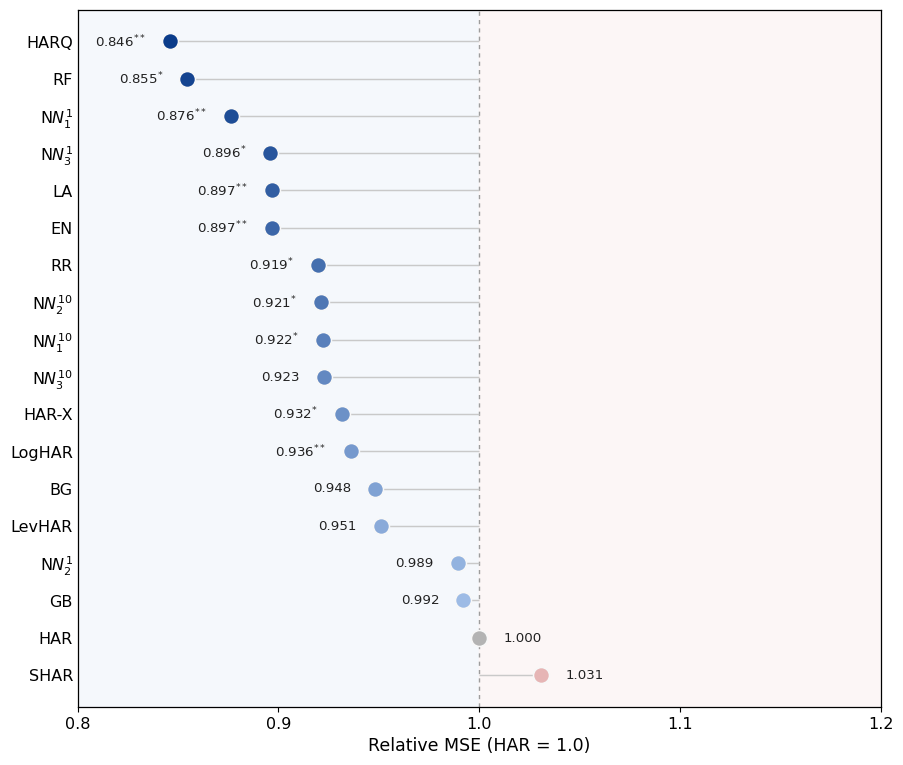

In [134]:
relative_to_har_alt = relative_to_har.copy()


def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)], dtype=float)


def rgb_to_hex(rgb):
    rgb = np.clip(np.round(rgb), 0, 255).astype(int)
    return "#%02x%02x%02x" % tuple(rgb)


def interpolate_hex(start_hex, end_hex, n):
    if n <= 0:
        return []
    if n == 1:
        return [start_hex]
    start_rgb = hex_to_rgb(start_hex)
    end_rgb = hex_to_rgb(end_hex)
    weights = np.linspace(0.0, 1.0, n)
    return [rgb_to_hex((1 - w) * start_rgb + w * end_rgb) for w in weights]


chart_label_map_alt = {
    "NN1_best": r"N$N_{1}^{1}$",
    "NN1_top10": r"N$N_{1}^{10}$",
    "NN2_best": r"N$N_{2}^{1}$",
    "NN2_top10": r"N$N_{2}^{10}$",
    "NN3_best": r"N$N_{3}^{1}$",
    "NN3_top10": r"N$N_{3}^{10}$",
}

plot_models = relative_to_har_alt.index.tolist()
plot_values = relative_to_har_alt.values

benchmark_models = [m for m in ["HAR"] if m in plot_models]
left_models = [m for m in plot_models if m not in benchmark_models and relative_to_har_alt[m] < 1.0]
right_models = [m for m in plot_models if m not in benchmark_models and relative_to_har_alt[m] > 1.0]

point_color_map = {m: "#b3b3b3" for m in benchmark_models}
for model, color in zip(left_models, interpolate_hex("#0b3c8a", "#9dbbe5", len(left_models))):
    point_color_map[model] = color
for model, color in zip(right_models, interpolate_hex("#e6b5b5", "#a50026", len(right_models))):
    point_color_map[model] = color

x_min, x_max = 0.8, 1.2
y_step = 1.28
y_pos = np.arange(len(plot_models)) * y_step
y_labels = [chart_label_map_alt.get(model, display_label_map.get(model, model)) for model in plot_models]

fig, ax = plt.subplots(figsize=(11.0, 8.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.axvspan(x_min, 1.0, color="#f5f8fc", zorder=0)
ax.axvspan(1.0, x_max, color="#fcf6f6", zorder=0)
ax.axvline(1.0, color="#9d9d9d", linestyle=(0, (3, 3)), linewidth=1.0, zorder=1)

for y, model, value in zip(y_pos, plot_models, plot_values):
    ax.hlines(y, 1.0, value, color="#c9c9c9", linewidth=1.05, zorder=1)
    ax.scatter(
        value,
        y,
        s=132,
        color=point_color_map[model],
        edgecolor="#f8f8f8",
        linewidth=1.1,
        zorder=3,
    )

    stars = "" if model == "HAR" else star_label(dm_pvalue_matrix.loc["HAR", model])
    label = rf"{value:.3f}$^{{{stars}}}$" if stars else f"{value:.3f}"
    offset = 0.012

    if value < 1.0:
        ax.text(value - offset, y, label, ha="right", va="center", fontsize=9.6, color="#222222", zorder=4)
    else:
        ax.text(value + offset, y, label, ha="left", va="center", fontsize=9.6, color="#222222", zorder=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=11.5)
ax.invert_yaxis()
ax.set_xlim(x_min, x_max)
ax.set_xticks(np.arange(0.8, 1.21, 0.1))
ax.set_xlabel("Relative MSE (HAR = 1.0)", fontsize=12.5)
ax.tick_params(axis="x", labelsize=11.5)
ax.tick_params(axis="y", length=0)

ax.grid(False, axis="x")
ax.grid(False, axis="y")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("#000000")
    ax.spines[spine].set_linewidth(0.9)

plt.subplots_adjust(left=0.23, right=0.96, top=0.95, bottom=0.10)
plt.show()


In [135]:
export_dir = Path("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results")
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / "MALL_Dot_plot.pdf"

if "fig" not in globals():
    raise RuntimeError("Run the Cleveland dot plot cell immediately above before exporting the figure.")

fig.savefig(export_path, format="pdf", bbox_inches="tight")
print(f"Saved figure to: {export_path}")


Saved figure to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/MALL_Dot_plot.pdf
